# Exploratory Data Analysis — Predicting Smartphone Addiction

This notebook explores the Kaggle Playground Series S6E8 dataset before model development.

The goal is to answer four practical questions:

1. What does the dataset look like?
2. How severe is missingness, and does train/test missingness differ?
3. Which variables show the strongest individual relationship with `addicted_label`?
4. What patterns should influence model and validation choices later?

**Task:** binary classification  
**Target:** `addicted_label`  
**Primary metric used later:** ROC-AUC


## 1. Load the data

The notebook supports both Kaggle and the local repository layout.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

kaggle_dir = Path("/kaggle/input/competitions/playground-series-s6e8")
local_dir = Path("../data")

data_dir = kaggle_dir if kaggle_dir.exists() else local_dir

train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")
sample_submission = pd.read_csv(data_dir / "sample_submission.csv")

print("Data directory:", data_dir)
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", sample_submission.shape)


The training set contains **691,369 rows and 14 columns**.  
The test set contains **296,302 rows and 13 columns**; the only train-only column is the target.


## 2. Schema and feature types

The dataset contains:
- 9 numerical predictors,
- 3 categorical predictors,
- `id`,
- the binary target `addicted_label`.


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

In [14]:
summary = pd.DataFrame({
    "dtype": train.dtypes,
    "missing_count": train.isnull().sum(),
    "missing_percent": train.isnull().mean() * 100,
    "n_unique": train.nunique()
})

summary

,dtype,missing_count,missing_percent,n_unique
id,int64,0,0.000000,691369
age,float64,28929,4.184307,18
daily_screen_time_hours,float64,95854,13.864376,1389
social_media_hours,float64,133995,19.381112,721
gaming_hours,float64,126821,18.343461,401
work_study_hours,float64,51518,7.451592,600
sleep_hours,float64,44480,6.433612,451
notifications_per_day,float64,67584,9.775388,231
app_opens_per_day,float64,80710,11.673940,166
weekend_screen_time,float64,112063,16.208855,1437


In [15]:
for col in ["gender", "stress_level", "academic_work_impact"]:
    print(f"\n--- {col} ---")
    print(train[col].value_counts(dropna=False))


--- gender ---
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

--- stress_level ---
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

--- academic_work_impact ---
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64


The categorical features are low-cardinality:
- `gender`: 3 observed categories,
- `stress_level`: 3 observed categories,
- `academic_work_impact`: 2 observed categories.

All three also contain missing values.


## 3. Target distribution

The positive class is more common but the task is not extremely imbalanced.


In [16]:
target_counts = train["addicted_label"].value_counts()
target_percent = train["addicted_label"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent
})

target_summary


,count,percentage
addicted_label,,
1,490474,70.942435
0,200895,29.057565


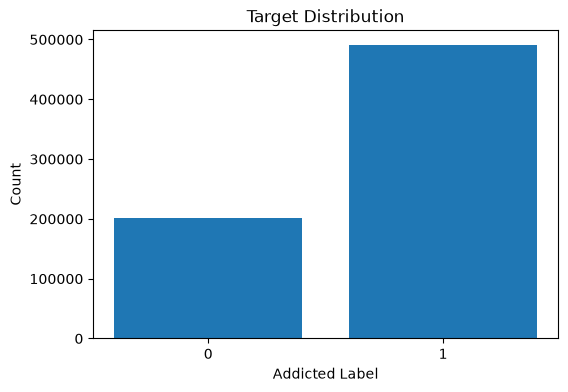

In [17]:
target_counts = train["addicted_label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)

plt.xlabel("Addicted Label")
plt.ylabel("Count")
plt.title("Target Distribution")

plt.show()

About **70.94%** of the training rows belong to class `1`, versus **29.06%** for class `0`.

Because the competition metric is ROC-AUC, the model is evaluated primarily on ranking quality rather than on a fixed probability threshold.


## 4. Missing values

Missingness is substantial across many predictors, especially screen-time-related variables.


In [14]:
summary = pd.DataFrame({
    "dtype": train.dtypes,
    "missing_count": train.isnull().sum(),
    "missing_percent": train.isnull().mean() * 100,
    "n_unique": train.nunique()
})

summary

,dtype,missing_count,missing_percent,n_unique
id,int64,0,0.000000,691369
age,float64,28929,4.184307,18
daily_screen_time_hours,float64,95854,13.864376,1389
social_media_hours,float64,133995,19.381112,721
gaming_hours,float64,126821,18.343461,401
work_study_hours,float64,51518,7.451592,600
sleep_hours,float64,44480,6.433612,451
notifications_per_day,float64,67584,9.775388,231
app_opens_per_day,float64,80710,11.673940,166
weekend_screen_time,float64,112063,16.208855,1437


The highest training-set missing rates are:

- `social_media_hours`: **19.38%**
- `gaming_hours`: **18.34%**
- `weekend_screen_time`: **16.21%**
- `daily_screen_time_hours`: **13.86%**
- `app_opens_per_day`: **11.67%**

This makes missing-value handling an important part of the modeling pipeline.


### Train vs. test missingness

A useful distribution-shift check is whether the missing-value pattern changes between train and test.


In [19]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain-only columns:")
print(set(train.columns) - set(test.columns))

print("\nTest-only columns:")
print(set(test.columns) - set(train.columns))

Train shape: (691369, 14)
Test shape: (296302, 13)

Train-only columns:
{'addicted_label'}

Test-only columns:
set()


In [20]:
feature_cols = [
    col for col in train.columns
    if col != "addicted_label"
]

dtype_comparison = pd.DataFrame({
    "train_dtype": train[feature_cols].dtypes,
    "test_dtype": test[feature_cols].dtypes
})

dtype_comparison

,train_dtype,test_dtype
id,int64,int64
age,float64,float64
daily_screen_time_hours,float64,float64
social_media_hours,float64,float64
gaming_hours,float64,float64
work_study_hours,float64,float64
sleep_hours,float64,float64
notifications_per_day,float64,float64
app_opens_per_day,float64,float64
weekend_screen_time,float64,float64


In [21]:
missing_comparison = pd.DataFrame({
    "train_missing_%": train[feature_cols].isna().mean() * 100,
    "test_missing_%": test[feature_cols].isna().mean() * 100
})

missing_comparison["difference"] = (
    missing_comparison["test_missing_%"]
    - missing_comparison["train_missing_%"]
)

missing_comparison.sort_values(
    "difference",
    key=abs,
    ascending=False
)

,train_missing_%,test_missing_%,difference
social_media_hours,19.381112,15.996180,-3.384932
app_opens_per_day,11.673940,8.675271,-2.998669
daily_screen_time_hours,13.864376,11.065737,-2.798639
academic_work_impact,6.396584,8.680670,2.284086
work_study_hours,7.451592,9.374557,1.922965
notifications_per_day,9.775388,11.549365,1.773978
gaming_hours,18.343461,20.053864,1.710403
age,4.184307,5.783964,1.599657
stress_level,7.976638,6.623647,-1.352990
sleep_hours,6.433612,7.578417,1.144804


The feature dtypes match between train and test, but missing rates are not identical.

The largest absolute differences include:
- `social_media_hours`: about **3.38 percentage points lower** missingness in test,
- `app_opens_per_day`: about **3.00 pp lower**,
- `daily_screen_time_hours`: about **2.80 pp lower**,
- `academic_work_impact`: about **2.28 pp higher**.

These differences are large enough to note, but they do not by themselves prove harmful covariate shift.


### Does missingness itself predict the target?

For every feature with missing values, compare the addiction rate when the value is missing versus present.


In [23]:
missing_target_analysis = []

for col in feature_cols:
    if train[col].isna().sum() > 0:

        missing_rate = train.loc[
            train[col].isna(),
            "addicted_label"
        ].mean()

        non_missing_rate = train.loc[
            train[col].notna(),
            "addicted_label"
        ].mean()

        missing_target_analysis.append({
            "feature": col,
            "addiction_rate_when_missing": missing_rate,
            "addiction_rate_when_present": non_missing_rate,
            "difference": missing_rate - non_missing_rate
        })

missing_target_df = pd.DataFrame(missing_target_analysis)

missing_target_df.sort_values(
    "difference",
    key=abs,
    ascending=False
)

,feature,addiction_rate_when_missing,addiction_rate_when_present,difference
5,sleep_hours,0.713377,0.709153,0.004224
0,age,0.713402,0.709251,0.004151
7,app_opens_per_day,0.712787,0.708980,0.003807
1,daily_screen_time_hours,0.711301,0.709122,0.002178
8,weekend_screen_time,0.710654,0.709187,0.001467
3,gaming_hours,0.710505,0.709182,0.001324
4,work_study_hours,0.710645,0.709326,0.001319
6,notifications_per_day,0.710242,0.709336,0.000906
9,gender,0.708790,0.709452,-0.000662
10,stress_level,0.709001,0.709461,-0.000460


The missingness-target differences are very small: the largest is only about **0.0042** in absolute addiction rate.

So missingness should be handled carefully, but there is little evidence here that a simple missing/not-missing flag is a strong standalone target signal.


## 5. Numerical signal strength

First compare class means using a standardized difference, then measure each numerical feature as a one-variable ROC-AUC predictor.


In [24]:
numerical_cols = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

comparison = pd.DataFrame({
    "not_addicted_mean": train.loc[
        train["addicted_label"] == 0, numerical_cols
    ].mean(),

    "addicted_mean": train.loc[
        train["addicted_label"] == 1, numerical_cols
    ].mean()
})

comparison["difference"] = (
    comparison["addicted_mean"]
    - comparison["not_addicted_mean"]
)

comparison["standardized_difference"] = (
    comparison["difference"]
    / train[numerical_cols].std()
)

comparison.sort_values(
    "standardized_difference",
    key=abs,
    ascending=False
)

,not_addicted_mean,addicted_mean,difference,standardized_difference
daily_screen_time_hours,5.042929,8.706523,3.663594,1.346194
weekend_screen_time,6.848920,10.558729,3.709809,1.298950
social_media_hours,1.376144,2.919495,1.543351,1.172637
work_study_hours,1.872582,2.569566,0.696984,0.553691
gaming_hours,1.159677,1.582119,0.422442,0.452026
app_opens_per_day,97.871440,104.592844,6.721405,0.139756
sleep_hours,6.722321,6.837970,0.115649,0.093680
notifications_per_day,147.087661,145.406142,-1.681519,-0.025509
age,26.582864,26.628749,0.045885,0.008904


In [26]:
from sklearn.metrics import roc_auc_score

univariate_results = []

for col in numerical_cols:
    temp = train[[col, "addicted_label"]].dropna()

    auc = roc_auc_score(
        temp["addicted_label"],
        temp[col]
    )

    univariate_results.append({
        "feature": col,
        "auc": auc,
        "predictive_strength": max(auc, 1 - auc),
        "direction": "higher -> addicted" if auc >= 0.5 else "lower -> addicted"
    })

univariate_auc = pd.DataFrame(univariate_results)

univariate_auc.sort_values(
    "predictive_strength",
    ascending=False
)

,feature,auc,predictive_strength,direction
1,daily_screen_time_hours,0.889550,0.889550,higher -> addicted
8,weekend_screen_time,0.880988,0.880988,higher -> addicted
2,social_media_hours,0.857782,0.857782,higher -> addicted
4,work_study_hours,0.654880,0.654880,higher -> addicted
3,gaming_hours,0.621960,0.621960,higher -> addicted
7,app_opens_per_day,0.540883,0.540883,higher -> addicted
5,sleep_hours,0.526953,0.526953,higher -> addicted
6,notifications_per_day,0.492145,0.507855,lower -> addicted
0,age,0.502272,0.502272,higher -> addicted


The strongest individual numerical predictors are:

| Feature | Univariate ROC-AUC |
|---|---:|
| `daily_screen_time_hours` | **0.88955** |
| `weekend_screen_time` | **0.88099** |
| `social_media_hours` | **0.85778** |
| `work_study_hours` | 0.65488 |
| `gaming_hours` | 0.62196 |

`age`, `notifications_per_day`, and `sleep_hours` are weak on their own.

The top three features already carry substantial signal, suggesting that the task has a strong behavioral-screen-time structure.


## 6. Non-linearity in daily screen time

The strongest feature is not merely correlated with the target; its relationship with addiction probability is highly nonlinear.


In [27]:
temp = train[
    ["daily_screen_time_hours", "addicted_label"]
].dropna().copy()

temp["screen_time_bin"] = pd.qcut(
    temp["daily_screen_time_hours"],
    q=10
)

screen_time_analysis = (
    temp.groupby(
        "screen_time_bin",
        observed=True
    )
    .agg(
        count=("addicted_label", "size"),
        mean_screen_time=("daily_screen_time_hours", "mean"),
        addiction_rate=("addicted_label", "mean")
    )
)

screen_time_analysis

,count,mean_screen_time,addiction_rate
screen_time_bin,,,
"(0.499, 3.97]",60024,3.049675,0.265061
"(3.97, 4.96]",59307,4.453047,0.310385
"(4.96, 5.89]",59443,5.469918,0.398567
"(5.89, 6.8]",59593,6.346242,0.534341
"(6.8, 7.77]",59671,7.299600,0.723417
"(7.77, 8.7]",59671,8.260704,0.895326
"(8.7, 9.47]",60152,9.111156,0.974265
"(9.47, 10.25]",58917,9.865319,0.994738
"(10.25, 11.24]",59730,10.741262,0.998661


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(
    screen_time_analysis["mean_screen_time"],
    screen_time_analysis["addiction_rate"],
    marker="o"
)
plt.xlabel("Mean daily screen time (hours)")
plt.ylabel("Addiction rate")
plt.title("Addiction Rate Across Daily Screen-Time Deciles")
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.show()


The addiction rate rises from about **26.5%** in the lowest screen-time decile to almost **100%** in the highest deciles.

This steep S-shaped pattern strongly motivates nonlinear models such as gradient-boosted trees rather than relying only on a linear decision boundary.


## 7. Categorical features

The categorical variables have much weaker separation than the main numerical features.


In [25]:
categorical_cols = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")

    result = train.groupby(
        col,
        dropna=False
    )["addicted_label"].agg(
        ["count", "mean"]
    )

    result = result.rename(
        columns={"mean": "addiction_rate"}
    )

    print(result)


--- gender ---
         count  addiction_rate
gender                        
Female  221595        0.703838
Male    223662        0.723198
Other   217078        0.701020
NaN      29034        0.708790

--- stress_level ---
               count  addiction_rate
stress_level                        
High          220873        0.711431
Low           207783        0.711160
Medium        207565        0.705663
NaN            55148        0.709001

--- academic_work_impact ---
                       count  addiction_rate
academic_work_impact                        
No                    316579        0.711029
Yes                   330566        0.707883
NaN                    44224        0.709456


The largest visible categorical difference is for `gender`: the addiction rate is about **72.32%** for `Male` versus about **70.10–70.38%** for the other observed categories.

`stress_level` and `academic_work_impact` show only small rate differences.

These variables may still contribute through interactions, but they are not strong standalone predictors.


## 8. Correlation among the strongest numerical features

The leading screen-time variables are related to each other, so it is useful to check redundancy before feature engineering.


In [28]:
top_features = [
    "daily_screen_time_hours",
    "weekend_screen_time",
    "social_media_hours",
    "work_study_hours",
    "gaming_hours"
]

train[top_features].corr()

,daily_screen_time_hours,weekend_screen_time,social_media_hours,work_study_hours,gaming_hours
daily_screen_time_hours,1.000000,0.800061,0.595578,0.525948,0.429343
weekend_screen_time,0.800061,1.000000,0.478053,0.417525,0.342106
social_media_hours,0.595578,0.478053,1.000000,0.100520,0.088203
work_study_hours,0.525948,0.417525,0.100520,1.000000,0.048995
gaming_hours,0.429343,0.342106,0.088203,0.048995,1.000000


`daily_screen_time_hours` and `weekend_screen_time` are strongly correlated (**0.80**).  
Daily screen time is also moderately correlated with social-media, work/study, and gaming time.

This suggests that useful engineered features may come from **relationships or inconsistencies among screen-time components**, not just from adding more raw versions of the same signal.


## 9. EDA conclusions

The EDA led to several modeling decisions:

- Use **stratified cross-validation** because the target is imbalanced at roughly 71/29.
- Prefer nonlinear tree models because the strongest feature-target relationships are highly nonlinear.
- Handle missing values inside the modeling pipeline and avoid assuming missingness itself is highly predictive.
- Pay attention to train/test differences in missingness.
- Treat the strongest screen-time features as partially redundant and test structural feature engineering rather than only generic ratios.
- Evaluate all feature engineering with out-of-fold ROC-AUC rather than relying on intuition.

These observations motivate the baseline experiments in `02_baseline.ipynb` and the advanced XGBoost work in `03_xgboost_advanced.ipynb`.
